# CNN(Convolution Neural Network, 합성곱 신경망)

## CNN 핵심 개념 정리

## 전체 흐름
입력 이미지 → **[합성곱 → 활성화 함수 → 풀링]** 반복 → **Flatten** → **Fully Connected** → 출력

CNN은 이 블록을 여러 번 쌓아 저수준 특징(선, 곡선)에서 고수준 특징(눈, 얼굴 형태 등)으로 점차 추상화합니다.

---

## 1. 필터 (Filter / Kernel) : 특징 찾기

- **무엇인가요?** 이미지 위를 훑고 지나가는 작은 격자판(보통 3x3 또는 5x5 크기)이자, 모델이 학습해야 할 가중치(Weight) 그 자체입니다.
- **왜 쓰나요?** 이미지를 일렬로 펴지 않고 2차원 모양 그대로 훑기 때문에, 공간 정보(위치 관계)를 파괴하지 않고 선, 면, 곡선 같은 지역적 특징을 찾아낼 수 있습니다.
- **채널과 깊이**: 필터는 하나가 아니라 여러 개(예: 32개, 64개)를 동시에 학습하며, 그 결과 여러 장의 특징 맵(Feature Map)이 채널 방향으로 쌓입니다. 입력 채널 수(예: RGB=3)와 필터의 채널 수는 항상 일치해야 합니다.

## 2. 패딩 (Padding) : 정보 손실 방지

- **무엇인가요?** 필터를 돌리기 전에 이미지 가장자리에 가상의 0을 둘러서 도화지를 넓혀주는 작업(`padding='same'`).
- **왜 쓰나요?**
  1. 필터를 거치면 원래 가장자리 데이터는 연산에 적게 참여해서 소외되는데, 이를 막아 외곽 특징도 골고루 학습하게 합니다.
  2. 층이 깊어질 때 이미지 크기가 순식간에 줄어들어 데이터가 소멸하는 것을 방지합니다.

## 3. 스트라이드 (Stride) : 필터의 이동 '보폭'

- **무엇인가요?** 필터가 이미지 위를 이동할 때 한 번에 몇 칸씩 건너뛰는지를 정하는 값입니다.
- **왜 쓰나요?** 출력 특징 맵의 크기와 연산량을 결정하는 핵심 하이퍼파라미터입니다. 스트라이드가 클수록 출력이 작아지고 연산이 줄어들지만 정보 손실 위험도 커집니다.
- **출력 크기 공식 참고**: `O = (I - F + 2P) / S + 1` (I=입력 크기, F=필터 크기, P=패딩, S=스트라이드)

## 4. 합성곱 (Convolution) : 격자판을 훑는 '수학적 연산'

- **무엇인가요?** 이미지 위에 필터를 포갠 뒤, 겹치는 칸끼리 곱하고 싹 다 더해서 새로운 숫자 하나를 만드는 훑기 과정입니다.
- **왜 쓰나요?** 필터 하나로 이미지 전체를 공유하며 훑기 때문에 연산 효율성(가중치 공유)이 극대화되고, 이미지 안에서 특징이 어디에 위치하든 찾아낼 수 있습니다.

## 5. 활성화 함수 (Activation Function, 주로 ReLU) : 비선형성 부여

- **무엇인가요?** 합성곱 결과에 적용하는 비선형 함수로, CNN에서는 주로 ReLU(음수는 0, 양수는 그대로)를 사용합니다.
- **왜 쓰나요?** 활성화 함수가 없으면 Conv 층을 아무리 깊게 쌓아도 결국 하나의 선형 변환과 다를 바 없습니다. 비선형성을 넣어야 복잡한 패턴(곡선, 형태 등)을 표현할 수 있습니다.

## 6. 풀링 (Pooling) : 핵심만 남기는 '압축기'

- **무엇인가요?** 합성곱으로 나온 결과물에서 일정 영역(보통 2x2)을 지정해 대표값만 남기고 나머지는 버리는 단계입니다. 가장 큰 값을 남기는 `MaxPooling2D`가 일반적이며, 평균값을 남기는 `AveragePooling`도 사용됩니다.
- **왜 쓰나요?**
  1. 데이터 크기를 줄여 연산 부담을 줄이고 속도를 높입니다.
  2. 불필요한 노이즈를 제거하여 과적합을 방지합니다.
  3. 물체의 미세한 위치 변화에도 모델이 흔들리지 않는 이동 불변성을 만들어 줍니다.
- **참고**: ResNet 등 최근 구조에서는 Pooling 대신 스트라이드 2의 Conv 층으로 크기를 줄이기도 합니다.

## 7. Flatten + Fully Connected : 특징을 결과로 연결

- **무엇인가요?** 반복된 Conv-풀링 블록을 거쳐 나온 다차원 특징 맵을 1차원 벡터로 펼친(Flatten) 뒤, 일반 신경망(Dense, Fully Connected)에 통과시켜 최종 클래스를 분류합니다.
- **왜 쓰나요?** Conv/Pooling이 '특징 추출' 역할이라면, Flatten + FC는 그 특징을 바탕으로 '최종 판단(분류)'을 내리는 역할입니다.

## 8. 왜 CNN인가 : 완전연결(MLP)과의 비교

- 100x100 크기 이미지를 완전연결 신경망으로 처리하면 입력층 노드만 10,000개가 되어 파라미터 수가 폭발적으로 늘어납니다.
- CNN은 작은 필터를 이미지 전체에 공유(가중치 공유)하기 때문에 파라미터 수를 획기적으로 줄이면서도 위치에 무관하게 특징을 검출할 수 있습니다.

## 0. 환경설정

In [59]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Reshape
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

## 1. fashion_mnist 실습

In [4]:
# 실습 1-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print(x_train.shape, y_test.shape)

(60000, 28, 28) (10000,)


In [5]:
# 실습 1-1 모델 적용 전 전처리

# 정규화
x_train = x_train[:,:,:,np.newaxis] / 255
x_test = x_test[:,:,:,np.newaxis] / 255


# 라벨 원-핫 인코딩
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(x_train.shape, y_train.shape)

(60000, 28, 28, 1) (60000, 10)


In [8]:
def learning_plot(hist):
    plt.figure(figsize=(12, 5))

    # 오차(Loss) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Loss')
    plt.xlabel('Epoch')

    # 정확도(Accuracy) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()
    plt.title('Accuracy')
    plt.xlabel('Epoch')

    plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,986 (214.79 KB)

 Trainable params: 54,986 (214.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.8309 - loss: 0.4680 - val_accuracy: 0.8749 - val_loss: 0.3597
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8877 - loss: 0.3102 - val_accuracy: 0.8856 - val_loss: 0.3155
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9019 - loss: 0.2675 - val_accuracy: 0.8973 - val_loss: 0.2804
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9133 - loss: 0.2379 - val_accuracy: 0.8990 - val_loss: 0.2799
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9204 - loss: 0.2143 - val_accuracy: 0.9073 - val_loss: 0.2628
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9287 - loss: 0.1970 - val_accuracy: 0.9111 - val_loss: 0.2600
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9334 - loss: 0.1790 - val_accuracy: 0.9102 - val_loss: 0.2541
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9381 -

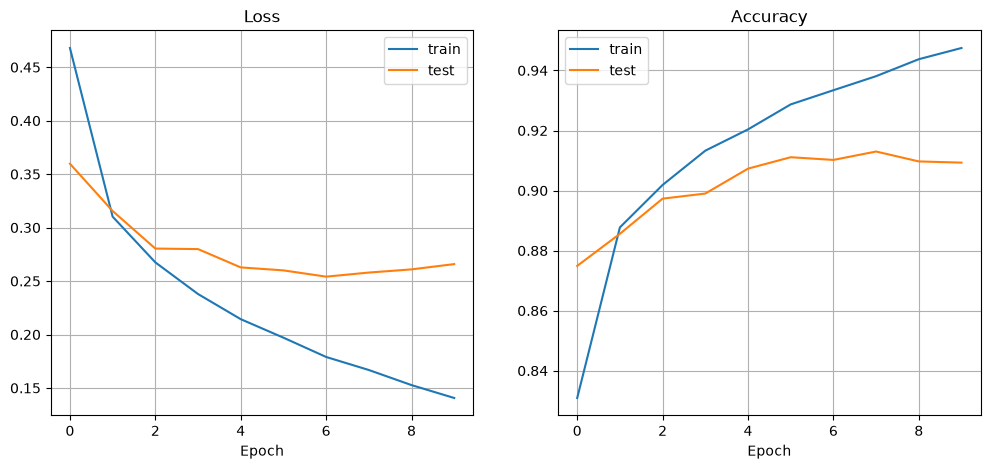

In [ ]:
# 실습 1-2 CNN 모델 설계

model = Sequential()
model.add(Input(shape=(28,28,1)))         # 28 * 28,  1은 흑백 이미지 의미

# Conv2D (합성곱층): 이미지에 돋보기를 대고 훑으면서 선, 면, 굴곡 같은 특징(Feature)을 찾아내는 단계

model.add(Conv2D(filters=32,              # 이미지에서 32가지의 서로 다른 특징을 찾아내어 32장의 필터를 만듦
                 kernel_size=(5,5),       # 특징을 포착하는 돋보기(필터)의 크기가 5x5
                 padding='same',          # 이미지가 필터를 거치면서 크기가 작아지는 것을 막기 위해 가장자리에 가상의 0을 채워줍니다
                 activation='relu'))

# MaxPooling2D(맥스 풀링층): 중요한 정보만 남기고 이미지 크기를 줄여(다운샘플링) 컴퓨터의 연산 부담을 줄입니다
model.add(MaxPooling2D(pool_size=(2,2)))  # 2x2 영역에서 가장 숫자가 큰(특징이 강한) 값 하나만 쏙 뽑아냅니다. 가로·세로가 반토막 나서 이미지 크기가 14x14로 줄어듭니다

# 총 3개의 합성곱층임
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2))) # 7*7
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2))) # 3*3


model.add(Flatten())                       # 3차원(가로 x 세로 x 채널)으로 쪼개져 있던 이미지 특징 데이터를 일반 신경망에 넣을 수 있도록 1차원 전선처럼 길게 한 줄로 펴주는 역할
model.add(Dense(10, activation='softmax')) # 출력층 : 원핫 인코딩이 10개라서 10으로 출력

model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)

learning_plot(hist)

## 2. Dogs_n_Cats 실습

In [ ]:
# 실습 2-0 데이터 불러오기

cat_files = glob.glob('./Dogs_n_Cats/Cats/*.jpg')
dog_files = glob.glob('./Dogs_n_Cats/Dogs/*.jpg')

In [21]:
# 실습 2-1 이미지 담기

img_size = 100  # 이미지를 100x100 크기로 통일

def load_images(file_list, label):  # 이미지 불러오기 함수
    images, labels = [], []
    for f in file_list:
#       해석 = Image. '파일' 열기.색상정보RGB.100*100 사이즈 조정
        img = Image.open(f).convert('RGB').resize((img_size, img_size)) 
        images.append(np.array(img)) # images에 array로 넣기
        labels.append(label)         # label 추가
    return images, labels

cat_images, cat_labels = load_images(cat_files, 0)  # 고양이: 0 으로 라벨 붙이기
dog_images, dog_labels = load_images(dog_files, 1)  # 개: 1 로 하벨 붙이기

x = np.array(cat_images + dog_images)
y = np.array(cat_labels + dog_labels)

print(x.shape, y.shape)

(202, 100, 100, 3) (202,)


In [ ]:
# 실습 2-1 이미지 담기(교수님 ver)
'''
x_data=[]
y_data=[]
for fn in glob.glob('./Dogs_n_Cats/*/*.jpg'):
    print(fn)
    img = Image.open(fn)
    img = img.resize((100,100))
    ndimg = np.array(img)
    x_data.append(ndimg)
    if fn.split("/")[-1].startswith('cat'):
        y_data.append(0)
    if fn.split('/')[-1].startswith('dog'):
        y_data.append(1)
    else:
        print("file name is not valid")
        break

x_data = np.array(x_data)
y_data = np.array(y_data)

print(x_data.shape,y_data.shape)

'''

'\nx_data=[]\ny_data=[]\nfor fn in glob.glob(\'./Dogs_n_Cats/*/*.jpg\'):\n    print(fn)\n    img = Image.open(fn)\n    img = img.resize((100,100))\n    ndimg = np.array(img)\n    x_data.append(ndimg)\n    if fn.split("/")[-1].startswith(\'cat\'):\n        y_data.append(0)\n    if fn.split(\'/\')[-1].startswith(\'dog\'):\n        y_data.append(1)\n    else:\n        print("file name is not valid")\n        break\n\nx_data = np.array(x_data)\ny_data = np.array(y_data)\n\nprint(x_data.shape,y_data.shape)\n'

In [22]:
# 실습 2-2 데이터 분리

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    stratify = y,
                                                    random_state=260713)

print(x_train.shape, y_train.shape)

(151, 100, 100, 3) (151,)


In [ ]:
# 실습 2-3 스케일 조정 및 원핫 인코딩

x_train_nm = x_train / 255
x_test_nm = x_test / 255

y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)

print(np.max(x_test_nm), y_test_oh.shape) # 확인

1.0 (51, 2)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 100, 100, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 50, 50, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │        36,866 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,722 (651.26 KB)

 Trainable params: 166,722 (651.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.4305 - loss: 0.7650
Epoch 1: val_loss improved from None to 0.70689, saving model to CnD.keras

Epoch 1: finished saving model to CnD.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 393ms/step - accuracy: 0.4305 - loss: 0.7650 - val_accuracy: 0.4902 - val_loss: 0.7069
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5033 - loss: 0.6996
Epoch 2: val_loss improved from 0.70689 to 0.69218, saving model to CnD.keras

Epoch 2: finished saving model to CnD.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.5033 - loss: 0.6996 - val_accuracy: 0.4902 - val_loss: 0.6922
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5033 - loss: 0.6896
Epoch 3: val_loss improved from 0.69218 to 0.69156, saving model to CnD.keras

Epoch 3: finished saving model to CnD.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.5033 - loss: 0.6896 - val_accuracy: 0.4902 - val_loss: 0.6916
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━

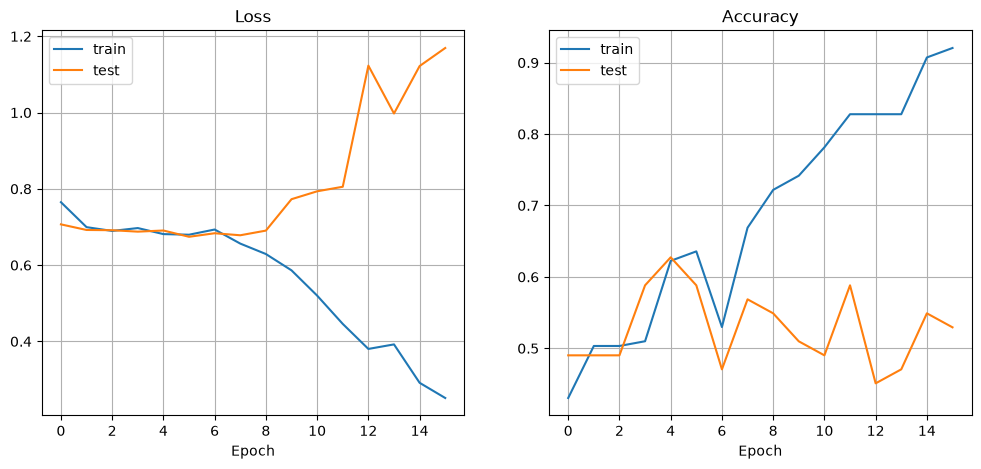

In [ ]:
# 실습 2-4 CNN 모델 설계

esc = EarlyStopping(monitor='val_loss', patience = 10)
chk = ModelCheckpoint(filepath='CnD.keras',  # 모델 저장
                      monitor='val_loss',    # 테스트 오차 기준으로
                      save_best_only=True,   # 가장 좋은 상태를 저장
                      verbose=3)             # 처리 과정 표시

model = Sequential()
model.add(Input(shape=(100,100,3)))         # 100 * 100,  3은 RGB 이미지 의미
model.add(Conv2D(filters=32, kernel_size=(7,7), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))    # 50*50
model.add(Conv2D(filters=64, kernel_size=(5,5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))    # 25*25
model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))    # 12*12
model.add(Flatten())                       
model.add(Dense(2, activation='softmax')) 
model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
hist = model.fit(x_train_nm, y_train_oh,
                  validation_data=(x_test_nm, y_test_oh),
                  callbacks = [esc,chk],
                  epochs=100)
learning_plot(hist)

In [39]:
# 실습 2-5 예측해보기

model.predict(x_test_nm[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


array([[0.99239177, 0.00760821]], dtype=float32)

In [40]:
# 실습 2-6 사진으로 예측해보기

img = Image.open('../Day_05/Test/hm.jpg').convert('RGB').resize((100, 100))
ndimg = np.array(img)
myimg = ndimg[np.newaxis, :] / 255
print(myimg.shape)
pred = model.predict(myimg)
labels = ['Cat', 'Dog']

for label, prob in zip(labels, pred[0]):
    print(f'{label}: {prob*100:.2f}%')

print(f'예측 결과: {labels[np.argmax(pred)]} ({np.max(pred)*100:.2f}%)')


(1, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Cat: 98.34%
Dog: 1.66%
예측 결과: Cat (98.34%)


In [ ]:
# 실습 2-7 저장된 모델 활용

bst_model = load_model("CnD.keras")
bst_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 100, 100, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 50, 50, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │        36,866 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,168 (1.91 MB)

 Trainable params: 166,722 (651.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 333,446 (1.27 MB)

## 3. Mnist 실습

In [45]:
# 실습 3-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [46]:
# 실습 3-1 데이터 전처리

# 정규화 + 채널 차원 추가 (흑백이라 채널 1)
x_train = x_train[:,:,:,np.newaxis] / 255
x_test = x_test[:,:,:,np.newaxis] / 255

# 라벨 원-핫 인코딩
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(x_train.shape, y_train.shape)

(60000, 28, 28, 1) (60000, 10)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,922 (1.74 MB)

 Trainable params: 454,922 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.9573 - loss: 0.1381 - val_accuracy: 0.9877 - val_loss: 0.0374
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9853 - loss: 0.0487 - val_accuracy: 0.9915 - val_loss: 0.0272
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9892 - loss: 0.0352 - val_accuracy: 0.9918 - val_loss: 0.0241
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9916 - loss: 0.0278 - val_accuracy: 0.9934 - val_loss: 0.0208
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9930 - loss: 0.0229 - val_accuracy: 0.9900 - val_loss: 0.0316
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9946 - loss: 0.0176 - val_accuracy: 0.9915 - val_loss: 0.0301
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9947 - loss: 0.0159 - val_accuracy: 0.9924 - val_loss: 0.0282
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9953 -

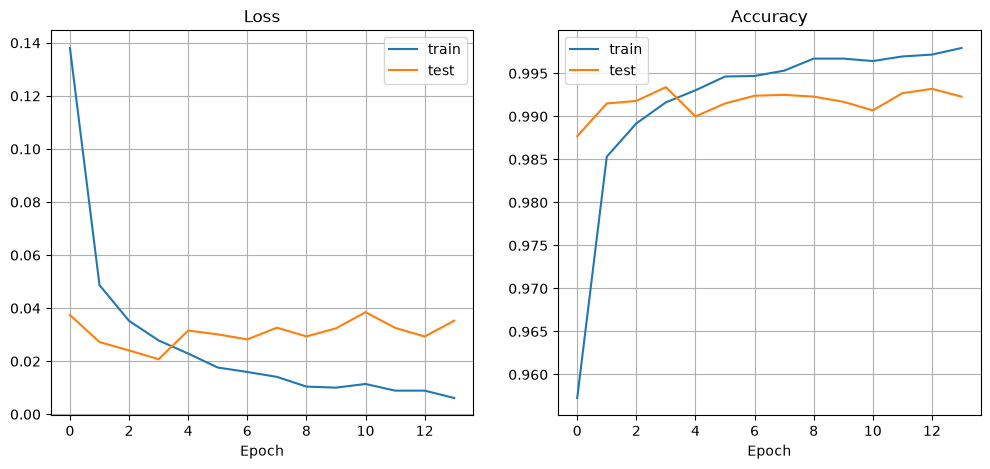

In [ ]:
# 실습 3-2 CNN 모델 설계

esc = EarlyStopping(monitor='val_loss', patience = 10)

model = Sequential()
model.add(Input(shape=(28,28,1)))         
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))  
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())                   
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))     
model.add(Dense(10, activation='softmax')) 
model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
hist = model.fit(x_train, y_train, 
                 validation_data=(x_test, y_test), 
                 callbacks = esc, 
                 epochs=30)

learning_plot(hist)

In [ ]:
# 실습 3-3-1 인코더
# 모은 데이터를 활용해서 패턴을 만드는 것

encoder = Sequential()
encoder.add(Input(shape=(28,28,1)))         
encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))  
encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))  
encoder.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
encoder.add(MaxPooling2D(pool_size=(2,2)))  
encoder.add(Flatten())
encoder.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 288)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,816 (73.50 KB)

 Trainable params: 18,816 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 실습 3-3-2 디코더
# 인코더로 모은 패턴으로 역으로 만들어가기

decoder = Sequential()
decoder.add(Input(shape=(288,)))
decoder.add(Dense(7*7*16))
decoder.add(Dense(14*14*16))
decoder.add(Dense(28*28, activation='sigmoid'))  # 최초 입력이 0~1이었으니까. 시그모이드
decoder.add(Reshape((28,28,1)))
decoder.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 784)            │       226,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3136)           │     2,461,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 784)            │     2,459,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,147,744 (19.64 MB)

 Trainable params: 5,147,744 (19.64 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# 실습 3-3-3 인코더 + 디코더

encoder_input = Input(shape = (28,28,1))
encoder_output = encoder(encoder_input)
decoder_output = decoder(encoder_output)
autoencoder = Model(encoder_input, decoder_output)
autoencoder.summary()
autoencoder.compile(loss='binary_crossentropy', optimizer='adam')

autoencoder.fit(x_train, x_train,
                validation_data=(x_test,x_test),
                epochs=10)

Model: "functional_133"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 288)            │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_20 (Sequential)      │ (None, 28, 28, 1)      │     5,147,744 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,166,560 (19.71 MB)

 Trainable params: 5,166,560 (19.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 105s 54ms/step - loss: 0.1090 - val_loss: 0.0847
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 101s 54ms/step - loss: 0.0820 - val_loss: 0.0785
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 100s 53ms/step - loss: 0.0781 - val_loss: 0.0758
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 104s 55ms/step - loss: 0.0760 - val_loss: 0.0744
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 107s 57ms/step - loss: 0.0747 - val_loss: 0.0738
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 109s 58ms/step - loss: 0.0738 - val_loss: 0.0728
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - loss: 0.0731 - val_loss: 0.0721
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 103s 55ms/step - loss: 0.0726 - val_loss: 0.0719
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 54ms/step - loss: 0.0722 - val_loss: 0.0715
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 55ms/step - loss: 0.0719 - val_loss: 0.0714
